In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import product

sns.set_theme(style="whitegrid")

# Full simulation walltimes (per run)
df4  = pd.read_csv('../output/walltimes_4_ranks.csv')
df16 = pd.read_csv('../output/walltimes_16_ranks.csv')

# Halo exchange timing (per iteration)
h4  = pd.read_csv('../output/halo_exchange_4_ranks.csv')
h16 = pd.read_csv('../output/halo_exchange_16_ranks.csv')

# Kernel timing (per iteration)
k4  = pd.read_csv('../output/kernel_timing_4_ranks.csv')
k16 = pd.read_csv('../output/kernel_timing_16_ranks.csv')

# y-lim so all whiskers are visible, no outlier space ---
def get_whisker_range(data, col):
    groups = data.groupby('topology')[col]
    lo_vals, hi_vals = [], []
    for _, vals in groups:
        q1, q3 = vals.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo_vals.append(max(vals.min(), q1 - 1.5 * iqr))
        hi_vals.append(min(vals.max(), q3 + 1.5 * iqr))
    return (min(lo_vals), max(hi_vals))

# padding for ylim
def ylim_with_pad(data, col, pad_frac=0.20):
    ymin, ymax = get_whisker_range(data, col)
    pad = (ymax - ymin) * pad_frac
    return (ymin - pad, ymax + pad)

# canonical topology order: x-ranks descending, then y-ranks descending
def topo_sort(values):
    return sorted(values, key=lambda t: (-int(t.split('x')[0]), -int(t.split('x')[1])))

# per-topology viridis colors, same order that the boxplots use
def topo_colors(values):
    order = topo_sort(values)
    cmap = sns.color_palette('viridis', len(order))
    return dict(zip(order, cmap))

def darken(c, factor=0.55):
    from matplotlib.colors import to_rgb
    r, g, b = to_rgb(c)
    return (r * factor, g * factor, b * factor)

# boxplot with consistent style
def boxplot(df, x, y, ax, title, ylabel, ylim=None, order=None):
    if order is None:
        order = topo_sort(df[x].unique())
    sns.boxplot(data=df, x=x, y=y, order=order,
                palette='viridis', hue=x, legend=False,
                linewidth=2, showfliers=False, ax=ax)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Topology', fontsize=12, labelpad=8)
    ax.set_ylabel(ylabel, fontsize=12, labelpad=8)
    if ylim is not None:
        ax.set_ylim(ylim)
    return ax

# Basic Benchmarks

Total simulation walltime per run (from `gpu_topo_*_ranks_v3.csv`).
Each run executes nt=100 timesteps on the full global grid.

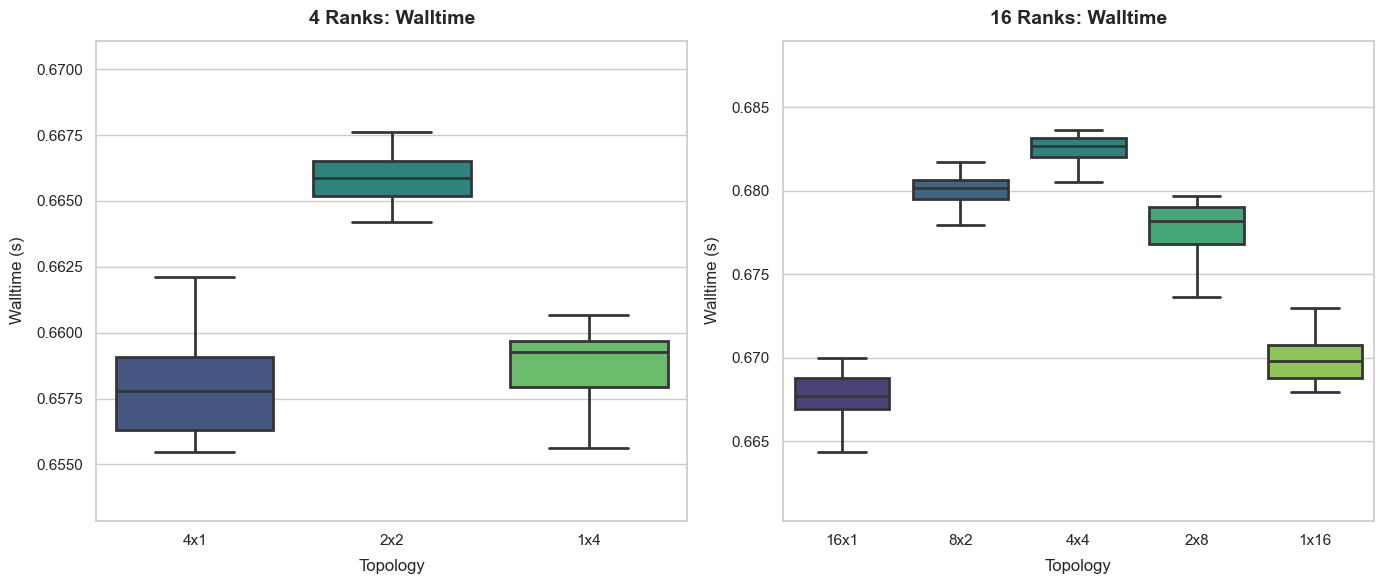

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

boxplot(df4, 'topology', 'walltime', axes[0],
        '4 Ranks: Walltime', 'Walltime (s)',
        ylim=ylim_with_pad(df4, 'walltime'))

boxplot(df16, 'topology', 'walltime', axes[1],
        '16 Ranks: Walltime', 'Walltime (s)',
        ylim=ylim_with_pad(df16, 'walltime'))

plt.tight_layout()
plt.show()


The x-axis shows the MPI rank decomposition (e.g. 4x1, 2x2, 1x4).
Lower walltime is better.

---
# Advanced Benchmark Metrics

Per-iteration profiling of compute kernels and MPI halo exchange.

In [3]:
# --- Compute derived metrics ---

# 1. Kernel throughput (Gcell/s): one value per kernel iteration
for df in [k4, k16]:
    df['kernel_mlups'] = df['nx_local'] * df['ny_local'] / df['kernel_walltime_seconds'] / 1e9

# 2. Communication Share: cross-product of kernel x halo iterations per topology
def compute_comm_share(halo_df, kernel_df):
    rows = []
    for topo in halo_df['topology'].unique():
        h_sub = halo_df[halo_df['topology'] == topo]
        k_sub = kernel_df[kernel_df['topology'] == topo]
        meta = h_sub.iloc[0][['nprocs','topology','nx_global','ny_global','nx_local','ny_local']].to_dict()
        for (_, hrow), (_, krow) in product(h_sub.iterrows(), k_sub.iterrows()):
            share = hrow['halo_walltime_seconds'] / (hrow['halo_walltime_seconds'] + krow['kernel_walltime_seconds']) * 100
            r = meta.copy()
            r['comm_share_pct'] = share
            rows.append(r)
    return pd.DataFrame(rows)

c4  = compute_comm_share(h4, k4)
c16 = compute_comm_share(h16, k16)

# 3. Total Effective Throughput (Gcell/s)
for df in [df4, df16]:
    interior = (df['nx_global'] - 2) * (df['ny_global'] - 2)
    df['total_mlups'] = interior * df['nt'] / df['walltime'] / 1e9
# 4. Communication Cost per Local Cell (ns)
for df in [h4, h16]:
    df['comm_cost_ns'] = df['halo_walltime_seconds'] / (df['nx_local'] * df['ny_local']) * 1e9


## Kernel Throughput (Gcell/s) & Communication Share

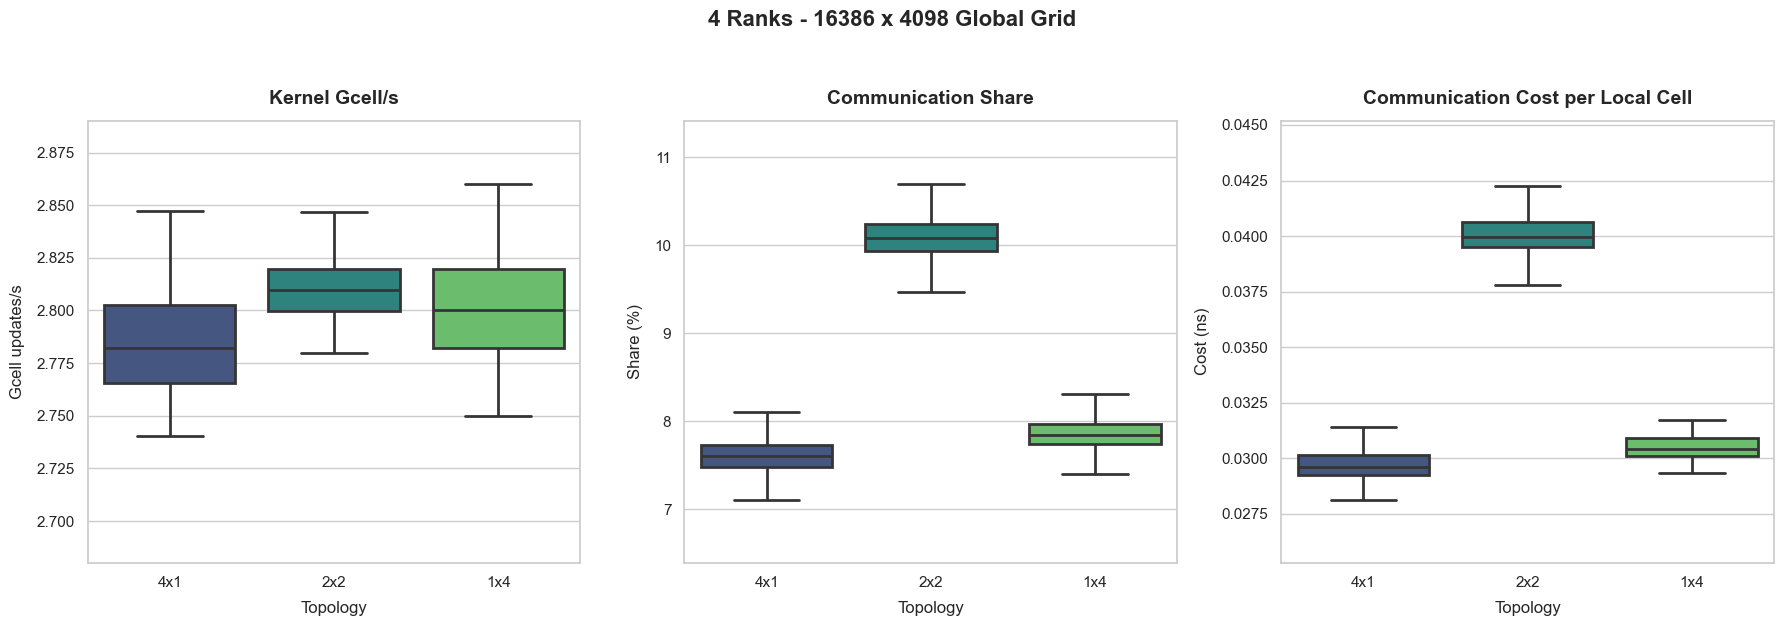

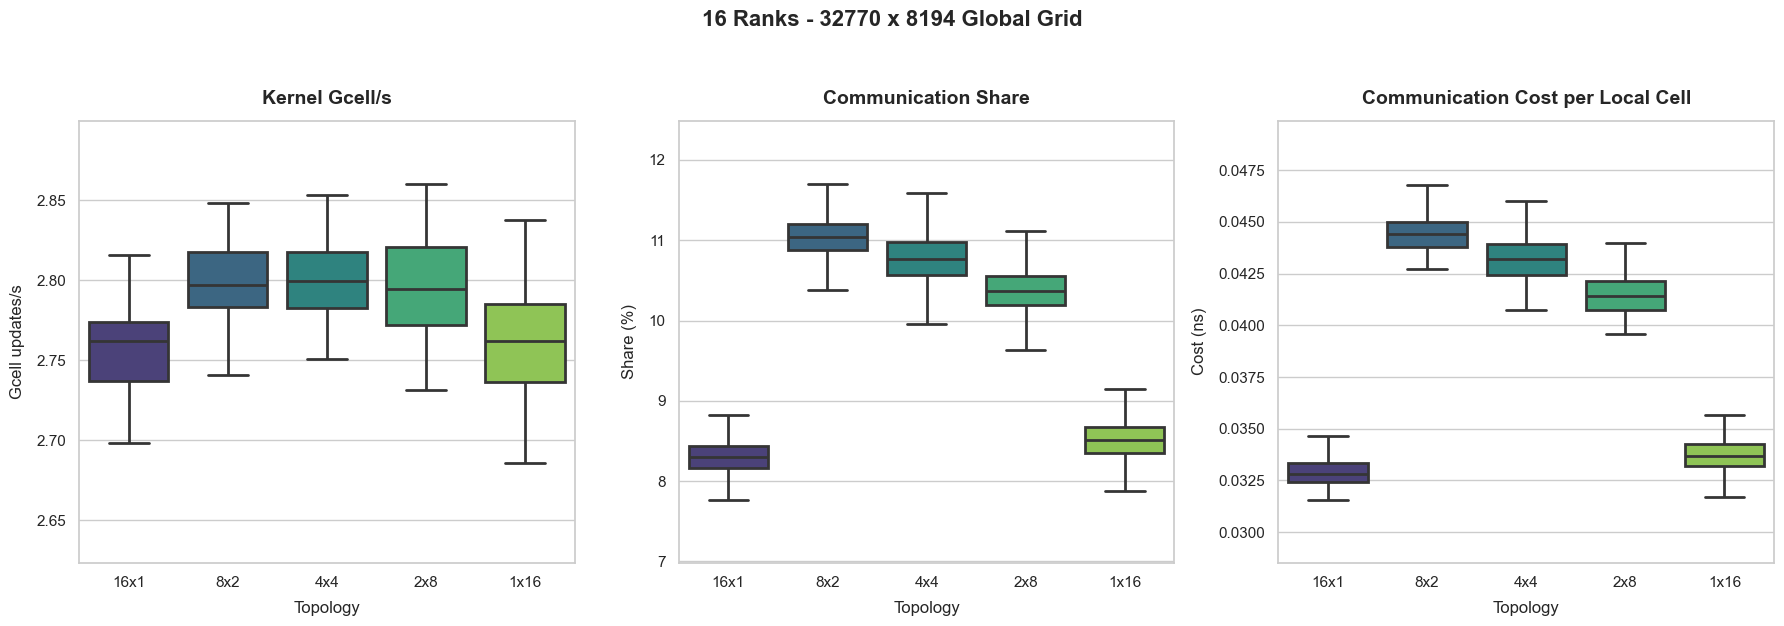

In [4]:
def plot_3panel(kdf, cdf, hdf, suptitle):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    boxplot(kdf, 'topology', 'kernel_mlups', axes[0],
            'Kernel Gcell/s', 'Gcell updates/s',
            ylim=ylim_with_pad(kdf, 'kernel_mlups'))
    boxplot(hdf, 'topology', 'comm_cost_ns', axes[2],
                        'Communication Cost per Local Cell', 'Cost (ns)',
                        ylim=ylim_with_pad(hdf, 'comm_cost_ns'))
    boxplot(cdf, 'topology', 'comm_share_pct', axes[1],
            'Communication Share', 'Share (%)',
            ylim=ylim_with_pad(cdf, 'comm_share_pct'))
    
    fig.suptitle(suptitle, fontsize=16, fontweight='bold', y=1.04)
    plt.tight_layout()
    plt.show()

plot_3panel(k4, c4, h4, '4 Ranks - 16386 x 4098 Global Grid')
plot_3panel(k16, c16, h16, '16 Ranks - 32770 x 8194 Global Grid')

## Total Effective Throughput (Gcell/s)


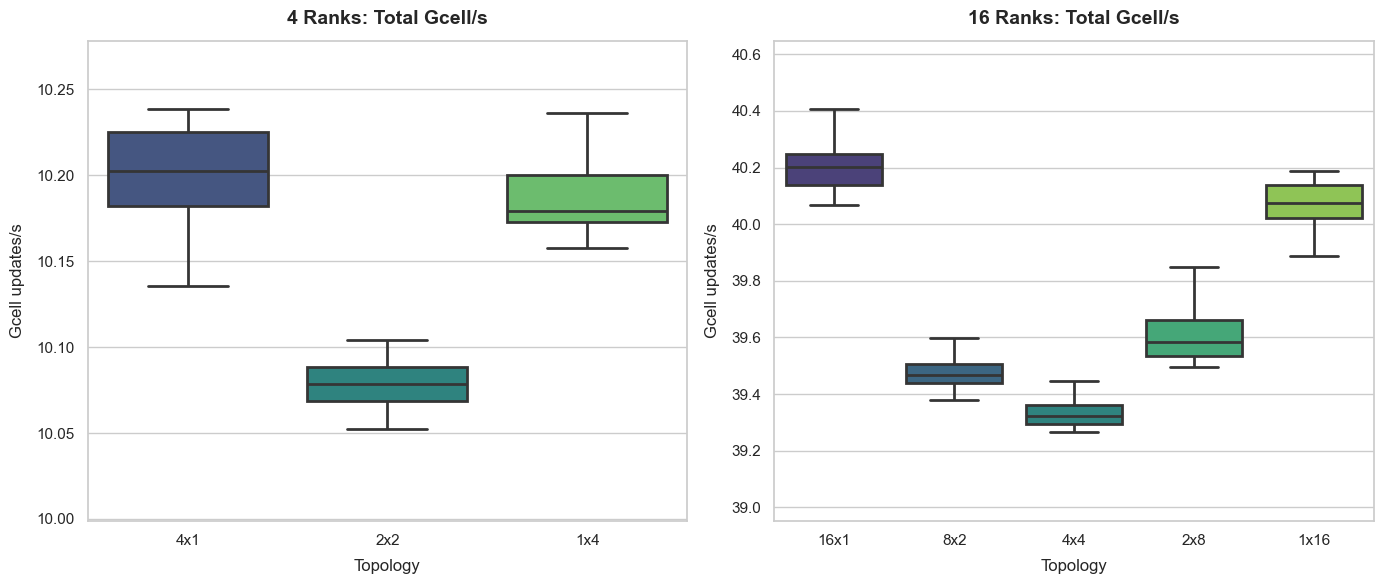

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

boxplot(df4, 'topology', 'total_mlups', axes[0],
        '4 Ranks: Total Gcell/s', 'Gcell updates/s',
        ylim=ylim_with_pad(df4, 'total_mlups'))

boxplot(df16, 'topology', 'total_mlups', axes[1],
        '16 Ranks: Total Gcell/s', 'Gcell updates/s',
        ylim=ylim_with_pad(df16, 'total_mlups'))

plt.tight_layout()
plt.show()


---
# Time per Iteration (Stacked)

Median kernel time per iteration at the bottom, with median MPI halo exchange
(communication) time stacked on top. Values are medians over all iterations per topology.

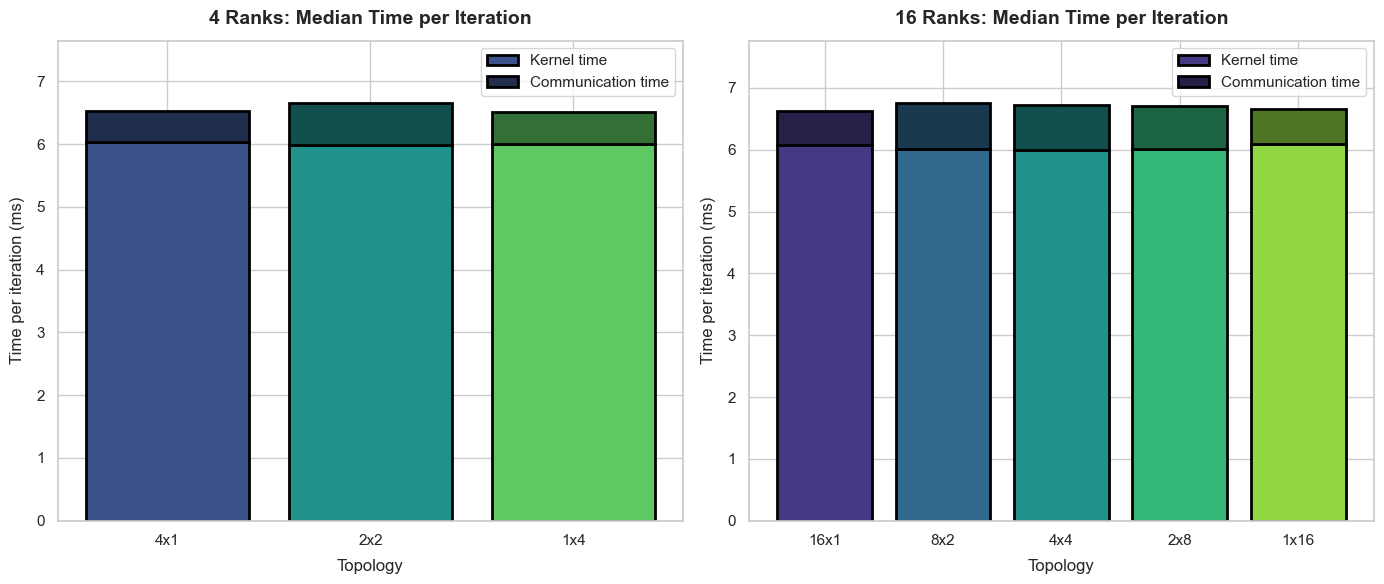

In [6]:
# --- Stacked medians: kernel (bottom) + comm (top), per topology ---

def stacked_time_data(kdf, hdf, order=None):
    rows = []
    if order is None:
        order = topo_sort(kdf['topology'].unique())
    for topo in order:
        k_med = kdf[kdf['topology'] == topo]['kernel_walltime_seconds'].median() * 1e3
        h_med = hdf[hdf['topology'] == topo]['halo_walltime_seconds'].median() * 1e3
        rows.append({'topology': topo,
                     'kernel_ms': k_med,
                     'comm_ms': h_med,
                     'total_ms': k_med + h_med})
    return pd.DataFrame(rows)

def plot_stacked_time(sdf, title, ax):
    x = np.arange(len(sdf))
    colors = [topo_colors(sdf['topology'])[t] for t in sdf['topology']]
    ax.bar(x, sdf['kernel_ms'], label='Kernel time',
           color=colors, linewidth=2, edgecolor='black')
    ax.bar(x, sdf['comm_ms'], bottom=sdf['kernel_ms'], label='Communication time',
           color=[darken(c) for c in colors], linewidth=2, edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(sdf['topology'])
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Topology', fontsize=12, labelpad=8)
    ax.set_ylabel('Time per iteration (ms)', fontsize=12, labelpad=8)
    ax.set_ylim(0, sdf['total_ms'].max() * 1.15)
    ax.legend(loc='upper right')
    return ax

s4  = stacked_time_data(k4, h4)
s16 = stacked_time_data(k16, h16)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_stacked_time(s4, '4 Ranks: Median Time per Iteration', axes[0])
plot_stacked_time(s16, '16 Ranks: Median Time per Iteration', axes[1])
plt.tight_layout()
plt.show()


---
# Time per Iteration & Communication Share

Left: median kernel time (bottom) with median communication (halo) time stacked on top.
Right: boxplots of the communication share per topology.

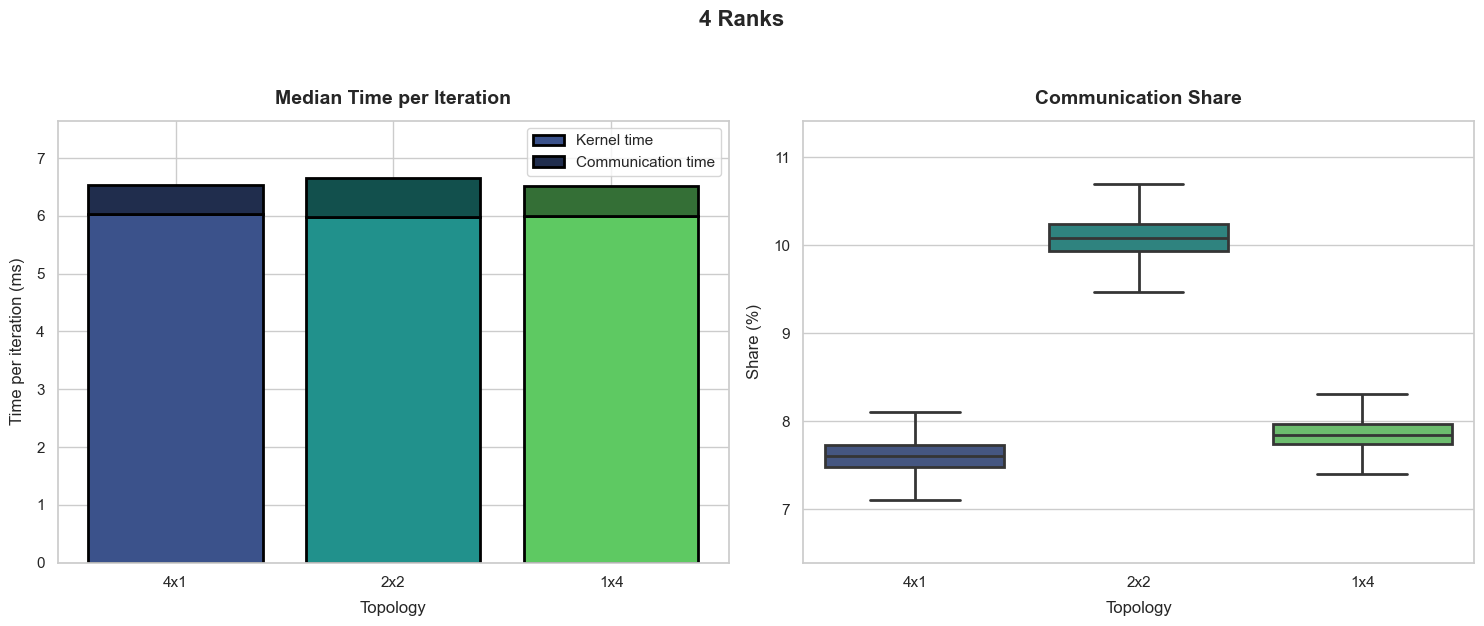

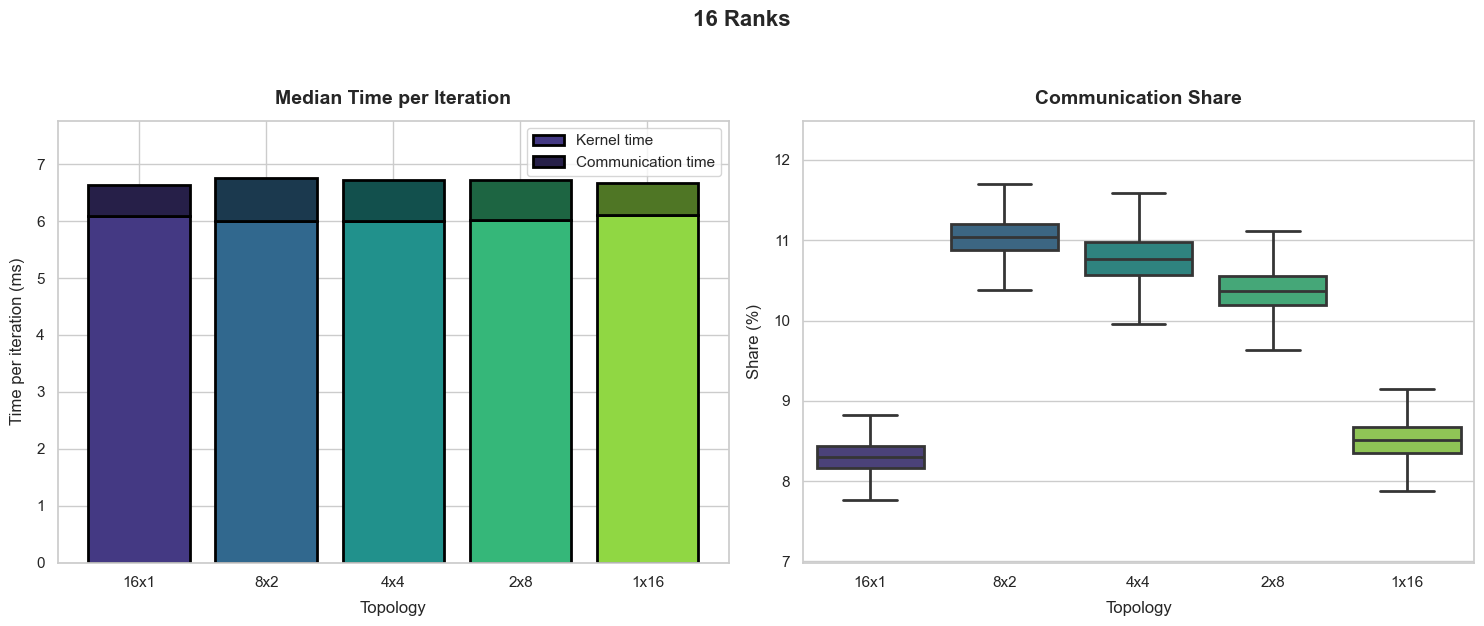

In [7]:
def plot_stacked_and_share(kdf, cdf, hdf, suptitle):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    plot_stacked_time(stacked_time_data(kdf, hdf), 'Median Time per Iteration', axes[0])
    boxplot(cdf, 'topology', 'comm_share_pct', axes[1],
            'Communication Share', 'Share (%)',
            ylim=ylim_with_pad(cdf, 'comm_share_pct'))
    fig.suptitle(suptitle, fontsize=16, fontweight='bold', y=1.04)
    plt.tight_layout()
    plt.show()

plot_stacked_and_share(k4, c4, h4, '4 Ranks')
plot_stacked_and_share(k16, c16, h16, '16 Ranks')


---
# Strong Scaling (Max)

Throughput (Gcell updates/s) versus global problem size for the baseline and manual domain decompositions.
Each CSV holds 5 repeated runs per (topology, size); the plotted value is the **max** of those runs.

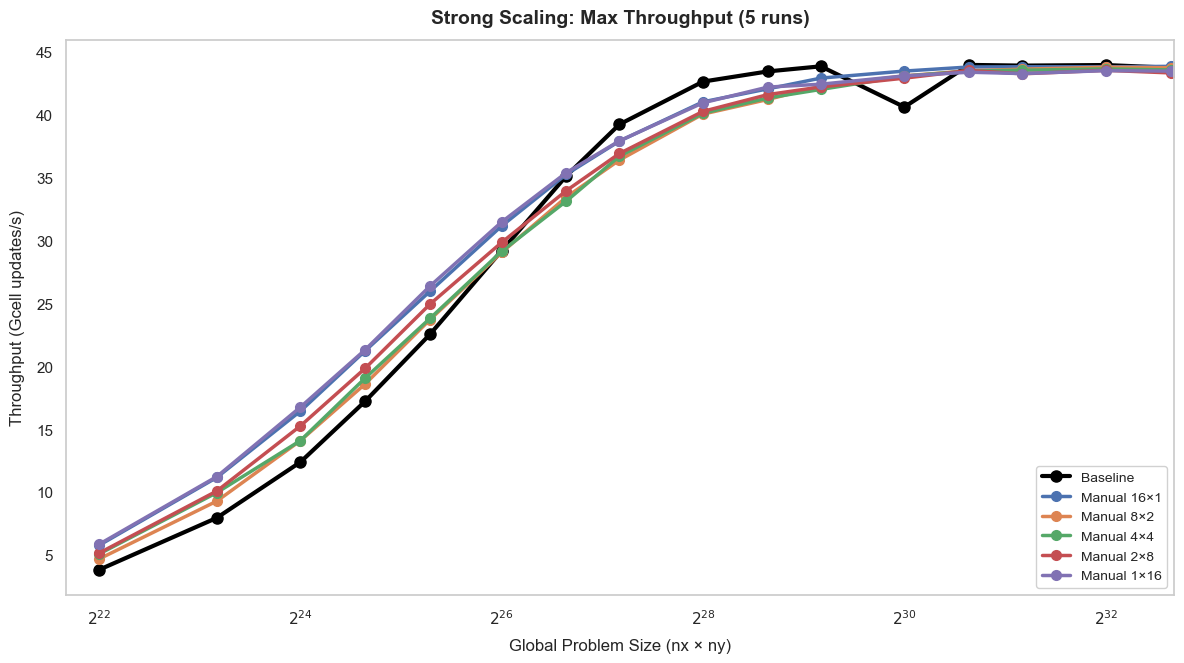

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

sc_baseline = pd.read_csv('../output/strong_scaling_baseline.csv')
sc_manual   = pd.read_csv('../output/strong_scaling_manual.csv')

def strong_scaling_max(df):
    """Group strong-scaling CSV by (topology, global size) and return median throughput."""
    df = df.copy()
    df['global_cells'] = df['nx_global'] * df['ny_global']
    df['throughput_g'] = df['cell_updates_per_second'] / 1e9
    med = (df.groupby(['solver', 'topology', 'global_cells'])['throughput_g']
             .max().reset_index())
    return med

def topo_sort(values):
    return sorted(values, key=lambda t: (-int(t.split('x')[0]), -int(t.split('x')[1])))

def plot_strong_scaling_max(df_base, df_manual, ax):
    b = strong_scaling_max(df_base)
    m = strong_scaling_max(df_manual)
    ax.plot(b['global_cells'], b['throughput_g'], '-o', color='black',
            linewidth=3, markersize=8, label='Baseline')
    for topo in topo_sort(m['topology'].unique()):
        sub = m[m['topology'] == topo].sort_values('global_cells')
        ax.plot(sub['global_cells'], sub['throughput_g'], '-o',
                linewidth=2.5, markersize=7,
                label=f"Manual {topo.replace('x', chr(0x00d7))}")
    cells = pd.concat([df_base[['nx_global', 'ny_global']], df_manual[['nx_global', 'ny_global']]])
    gmin, gmax = (cells['nx_global'] * cells['ny_global']).min(), (cells['nx_global'] * cells['ny_global']).max()
    e0 = int(math.floor(math.log2(gmin)))
    e1 = int(math.ceil(math.log2(gmax)))
    ticks  = [2 ** e for e in range(e0, e1 + 1, 2)]
    labels = [f'$2^{{{e}}}$' for e in range(e0, e1 + 1, 2)]
    ax.set_xscale('log', base=2)
    ax.set_xticks(ticks, labels=labels)
    ax.set_title('Strong Scaling: Max Throughput (5 runs)', fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Global Problem Size (nx \u00d7 ny)', fontsize=12, labelpad=8)
    ax.set_ylabel('Throughput (Gcell updates/s)', fontsize=12, labelpad=8)
    ax.set_xlim((1.6 * 2**21, 1.6 * 2**32))
    ax.grid(True, which='both', linewidth=1.5, color='white')
    ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
    return ax

fig, ax = plt.subplots(figsize=(12, 6.8))
plot_strong_scaling_max(sc_baseline, sc_manual, ax)
plt.tight_layout()
plt.show()


---

### Metric Definitions

| Metric | Formula | Data Source | Description |
|---|---|---|---|
| **Walltime** | measured total run time (s) | gpu_topo (per run) | End-to-end simulation time for nt=100 steps |
| **Kernel Throughput** | $\frac{\text{nx\_local} \times \text{ny\_local}}{\text{kernel\_runtime\_seconds}} \times 10^{-9}$ | kernel_timing (per iteration) | Pure compute throughput per rank (Gcell/s) |
| **Communication Share** | $\frac{t_{\text{halo}}}{t_{\text{kernel}} + t_{\text{halo}}} \times 100\%$ | cross-product of halo x kernel iterations | Fraction of iteration time spent on MPI halo exchange |
| **Total Throughput** | $\frac{(\text{nx\_global} - 2) \times (\text{ny\_global} - 2) \times \text{nt}}{\text{walltime}} \times 10^{-9}$ | gpu_topo (per run) | Overall simulation throughput (Gcell/s) |
| **Comm. Cost per Cell** | $\frac{t_{\text{halo}}}{\text{nx\_local} \times \text{ny\_local}} \times 10^{9}$ | halo_exchange (per iteration) | MPI overhead normalised by local grid size (ns per cell) |
